In [1]:
from pathlib import Path

PROJECT_ROOT = Path(r'C:\Users\vi\Sleep staging + fragmentation detection\sleep-staging-fragmentation')

RAW_DIR = PROJECT_ROOT / 'data' / 'raw'
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
FIGURES_DIR = PROJECT_ROOT / 'figures'

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(PROJECT_ROOT)
print(PROCESSED_DIR)
print(FIGURES_DIR)

C:\Users\vi\Sleep staging + fragmentation detection\sleep-staging-fragmentation
C:\Users\vi\Sleep staging + fragmentation detection\sleep-staging-fragmentation\data\processed
C:\Users\vi\Sleep staging + fragmentation detection\sleep-staging-fragmentation\figures


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
pred_path = PROCESSED_DIR / 'sleep_staging_cv_predictions_mini.csv'
pred_df = pd.read_csv(pred_path)

print(pred_df.shape)
pred_df.head()

(400, 4)


,subject_id,epoch_start_sec,stage_label,predicted_stage
0,SC4001,960.0,W,REM
1,SC4001,1290.0,W,W
2,SC4001,1320.0,W,REM
3,SC4001,1680.0,W,W
4,SC4001,2100.0,W,N3


In [4]:
print(pred_df['subject_id'].value_counts())
print()
print(pred_df['stage_label'].value_counts())
print()
print(pred_df['predicted_stage'].value_counts())

subject_id
SC4001    200
SC4002    200
Name: count, dtype: int64

stage_label
W      266
N3      55
N2      46
REM     26
N1       7
Name: count, dtype: int64

predicted_stage
W      235
N3      81
N2      50
REM     34
Name: count, dtype: int64


In [5]:
def compute_fragmentation_metrics(stage_sequence, epoch_duration_sec=30):
    seq = pd.Series(stage_sequence).reset_index(drop=True)

    n_epochs = len(seq)
    total_minutes = n_epochs * epoch_duration_sec / 60
    total_hours = n_epochs * epoch_duration_sec / 3600

    if n_epochs == 0:
        return {
            'n_epochs': 0,
            'total_minutes': 0,
            'total_hours': 0,
            'n_transitions': 0,
            'transitions_per_hour': np.nan,
            'wake_epochs': 0,
            'wake_minutes': 0,
            'wake_pct': np.nan,
            'wake_intrusions': 0,
            'fragmentation_index': np.nan
        }

    transitions = (seq != seq.shift()).sum() - 1
    transitions = max(transitions, 0)

    wake_epochs = (seq == 'W').sum()
    wake_minutes = wake_epochs * epoch_duration_sec / 60
    wake_pct = wake_epochs / n_epochs * 100

    wake_mask = (seq == 'W').astype(int)
    wake_starts = ((wake_mask == 1) & (wake_mask.shift(fill_value=0) == 0)).sum()
    wake_intrusions = int(wake_starts)

    transitions_per_hour = transitions / total_hours if total_hours > 0 else np.nan
    fragmentation_index = (transitions + wake_intrusions) / total_hours if total_hours > 0 else np.nan

    return {
        'n_epochs': n_epochs,
        'total_minutes': total_minutes,
        'total_hours': total_hours,
        'n_transitions': int(transitions),
        'transitions_per_hour': transitions_per_hour,
        'wake_epochs': int(wake_epochs),
        'wake_minutes': wake_minutes,
        'wake_pct': wake_pct,
        'wake_intrusions': wake_intrusions,
        'fragmentation_index': fragmentation_index
    }

In [6]:
rows = []

for subject_id, sub_df in pred_df.groupby('subject_id'):
    sub_df = sub_df.sort_values('epoch_start_sec').copy()

    true_metrics = compute_fragmentation_metrics(sub_df['stage_label'])
    pred_metrics = compute_fragmentation_metrics(sub_df['predicted_stage'])

    row = {'subject_id': subject_id}

    for k, v in true_metrics.items():
        row[f'true_{k}'] = v

    for k, v in pred_metrics.items():
        row[f'pred_{k}'] = v

    rows.append(row)

fragmentation_df = pd.DataFrame(rows)
fragmentation_df

,subject_id,true_n_epochs,true_total_minutes,true_total_hours,true_n_transitions,true_transitions_per_hour,true_wake_epochs,true_wake_minutes,true_wake_pct,true_wake_intrusions,...,pred_n_epochs,pred_total_minutes,pred_total_hours,pred_n_transitions,pred_transitions_per_hour,pred_wake_epochs,pred_wake_minutes,pred_wake_pct,pred_wake_intrusions,pred_fragmentation_index
0,SC4001,200,100.0,1.666667,23,13.8,143,71.5,71.5,3,...,200,100.0,1.666667,101,60.6,75,37.5,37.5,30,78.6
1,SC4002,200,100.0,1.666667,36,21.6,123,61.5,61.5,7,...,200,100.0,1.666667,25,15.0,160,80.0,80.0,11,21.6


In [7]:
fragmentation_df['diff_transitions'] = fragmentation_df['pred_n_transitions'] - fragmentation_df['true_n_transitions']
fragmentation_df['diff_wake_intrusions'] = fragmentation_df['pred_wake_intrusions'] - fragmentation_df['true_wake_intrusions']
fragmentation_df['diff_fragmentation_index'] = fragmentation_df['pred_fragmentation_index'] - fragmentation_df['true_fragmentation_index']

fragmentation_df

,subject_id,true_n_epochs,true_total_minutes,true_total_hours,true_n_transitions,true_transitions_per_hour,true_wake_epochs,true_wake_minutes,true_wake_pct,true_wake_intrusions,...,pred_n_transitions,pred_transitions_per_hour,pred_wake_epochs,pred_wake_minutes,pred_wake_pct,pred_wake_intrusions,pred_fragmentation_index,diff_transitions,diff_wake_intrusions,diff_fragmentation_index
0,SC4001,200,100.0,1.666667,23,13.8,143,71.5,71.5,3,...,101,60.6,75,37.5,37.5,30,78.6,78,27,63.0
1,SC4002,200,100.0,1.666667,36,21.6,123,61.5,61.5,7,...,25,15.0,160,80.0,80.0,11,21.6,-11,4,-4.2


In [8]:
frag_path = PROCESSED_DIR / 'fragmentation_metrics_mini.csv'
fragmentation_df.to_csv(frag_path, index=False)

print(frag_path)
print(frag_path.exists())

C:\Users\vi\Sleep staging + fragmentation detection\sleep-staging-fragmentation\data\processed\fragmentation_metrics_mini.csv
True


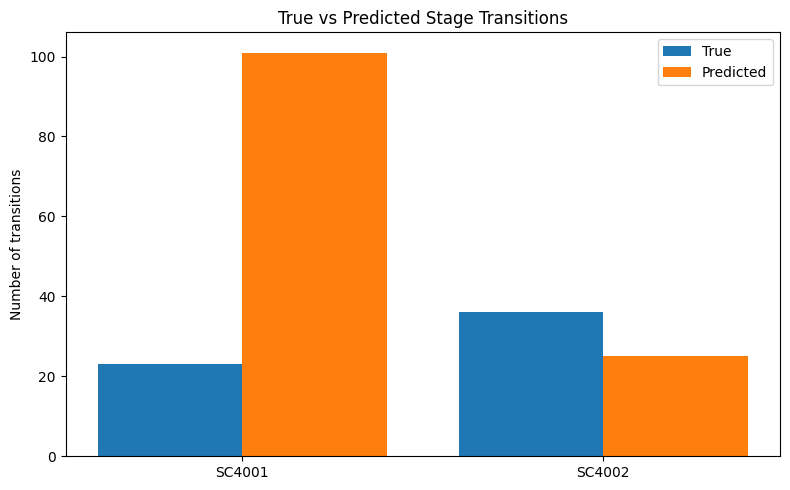

C:\Users\vi\Sleep staging + fragmentation detection\sleep-staging-fragmentation\figures\fragmentation_true_vs_pred_transitions_mini.png
True


In [9]:
plot_df = fragmentation_df.copy()
x = np.arange(len(plot_df))

plt.figure(figsize=(8, 5))
plt.bar(x - 0.2, plot_df['true_n_transitions'], width=0.4, label='True')
plt.bar(x + 0.2, plot_df['pred_n_transitions'], width=0.4, label='Predicted')

plt.xticks(x, plot_df['subject_id'])
plt.ylabel('Number of transitions')
plt.title('True vs Predicted Stage Transitions')
plt.legend()
plt.tight_layout()

fig_path = FIGURES_DIR / 'fragmentation_true_vs_pred_transitions_mini.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()

print(fig_path)
print(fig_path.exists())

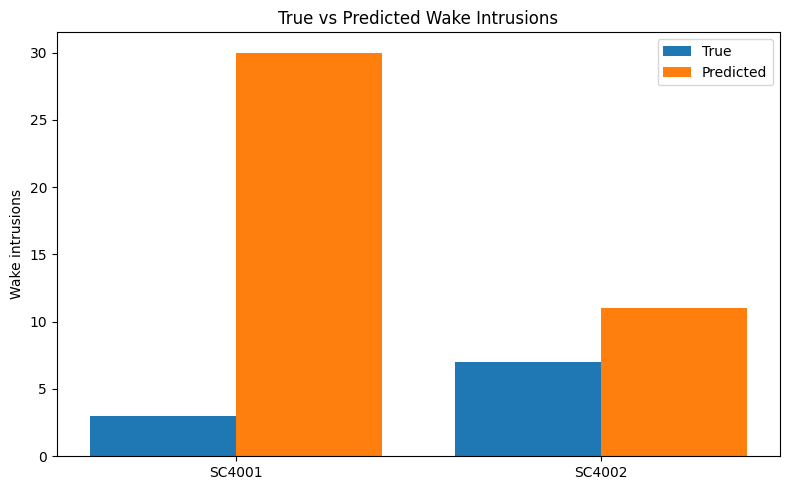

C:\Users\vi\Sleep staging + fragmentation detection\sleep-staging-fragmentation\figures\fragmentation_true_vs_pred_wake_intrusions_mini.png
True


In [11]:
plot_df = fragmentation_df.copy()
x = np.arange(len(plot_df))

plt.figure(figsize=(8, 5))
plt.bar(x - 0.2, plot_df['true_wake_intrusions'], width=0.4, label='True')
plt.bar(x + 0.2, plot_df['pred_wake_intrusions'], width=0.4, label='Predicted')

plt.xticks(x, plot_df['subject_id'])
plt.ylabel('Wake intrusions')
plt.title('True vs Predicted Wake Intrusions')
plt.legend()
plt.tight_layout()

fig_path = FIGURES_DIR / 'fragmentation_true_vs_pred_wake_intrusions_mini.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()

print(fig_path)
print(fig_path.exists())

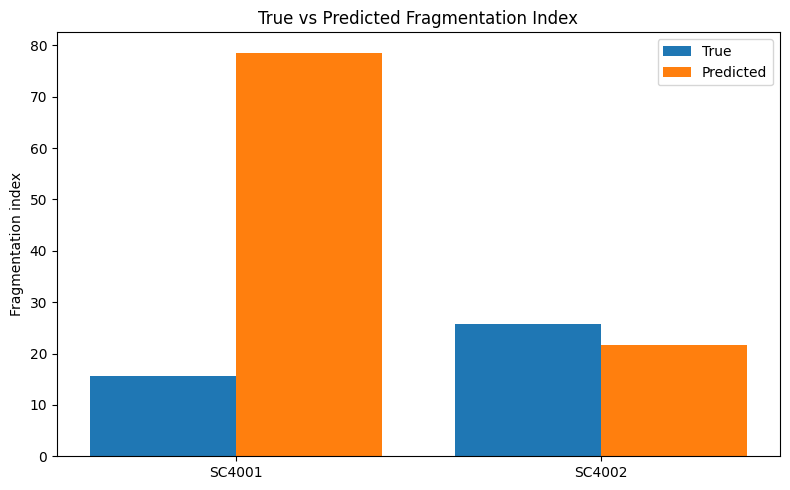

C:\Users\vi\Sleep staging + fragmentation detection\sleep-staging-fragmentation\figures\fragmentation_index_true_vs_pred_mini.png
True


In [12]:
plot_df = fragmentation_df.copy()
x = np.arange(len(plot_df))

plt.figure(figsize=(8, 5))
plt.bar(x - 0.2, plot_df['true_fragmentation_index'], width=0.4, label='True')
plt.bar(x + 0.2, plot_df['pred_fragmentation_index'], width=0.4, label='Predicted')

plt.xticks(x, plot_df['subject_id'])
plt.ylabel('Fragmentation index')
plt.title('True vs Predicted Fragmentation Index')
plt.legend()
plt.tight_layout()

fig_path = FIGURES_DIR / 'fragmentation_index_true_vs_pred_mini.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()

print(fig_path)
print(fig_path.exists())

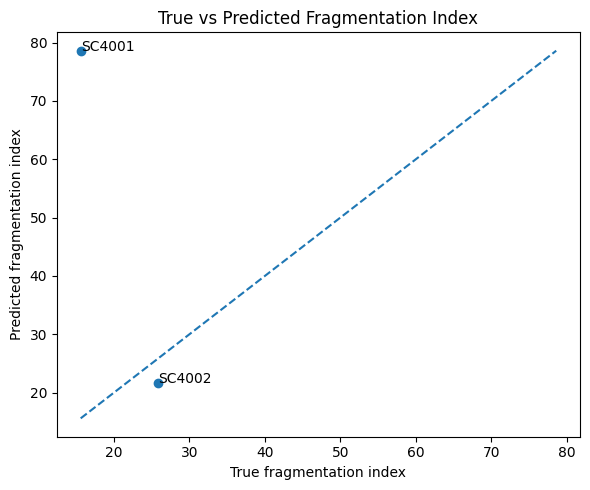

C:\Users\vi\Sleep staging + fragmentation detection\sleep-staging-fragmentation\figures\fragmentation_index_scatter_mini.png
True


In [13]:
plt.figure(figsize=(6, 5))
plt.scatter(
    fragmentation_df['true_fragmentation_index'],
    fragmentation_df['pred_fragmentation_index']
)

for _, row in fragmentation_df.iterrows():
    plt.annotate(
        row['subject_id'],
        (row['true_fragmentation_index'], row['pred_fragmentation_index'])
    )

min_val = min(fragmentation_df['true_fragmentation_index'].min(), fragmentation_df['pred_fragmentation_index'].min())
max_val = max(fragmentation_df['true_fragmentation_index'].max(), fragmentation_df['pred_fragmentation_index'].max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')
plt.xlabel('True fragmentation index')
plt.ylabel('Predicted fragmentation index')
plt.title('True vs Predicted Fragmentation Index')
plt.tight_layout()

fig_path = FIGURES_DIR / 'fragmentation_index_scatter_mini.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()

print(fig_path)
print(fig_path.exists())

In [14]:
summary_cols = [
    'subject_id',
    'true_n_transitions',
    'pred_n_transitions',
    'true_wake_intrusions',
    'pred_wake_intrusions',
    'true_fragmentation_index',
    'pred_fragmentation_index',
    'diff_fragmentation_index'
]

fragmentation_df[summary_cols]

,subject_id,true_n_transitions,pred_n_transitions,true_wake_intrusions,pred_wake_intrusions,true_fragmentation_index,pred_fragmentation_index,diff_fragmentation_index
0,SC4001,23,101,3,30,15.6,78.6,63.0
1,SC4002,36,25,7,11,25.8,21.6,-4.2


## Fragmentation interpretation

This notebook extends the sleep staging pipeline by deriving subject-level sleep fragmentation metrics from both true and predicted stage sequences.

The main goal is not only to classify sleep stages, but also to assess whether model outputs preserve clinically meaningful sleep stability patterns such as:
- stage transitions
- wake intrusions
- fragmentation burden

## Conclusion

The fragmentation analysis shows how epoch-level stage predictions can be translated into higher-level sleep stability metrics.

Even when stage-level classification is imperfect, predicted stage sequences may still retain useful subject-level information about fragmentation structure. This is important for neurotech applications where downstream sleep-quality summaries can be as valuable as raw stage predictions.

## Interpretation

The fragmentation analysis demonstrates that stage-level predictions can be converted into higher-level sleep stability summaries. This is important because many neurotech and sleep-tech applications rely not only on per-epoch staging, but also on interpretable subject-level sleep quality metrics.